# Decision Tree Classifier Training Project (with Post-Prunning): Iris Dataset
The data includes information about Iris Flowers, which is divided into 3 classes:

- 1 -> Iris-setosa.  
- 2 -> Iris-versicolor.  
- 3 -> Iris-virginica.

Dataset includes the following attributes:

- Sepal Length: Length of the sepal measured vertically.  
- Sepal Width: Width of the sepal measured horizontally.  
- Petal Length: Length of the petal measured vertically.  
- Petal Width: Width of the petal measured horizontally.  

In this project, we predict the class of the flower based on the attribute values.

**IMPORT REQUIRED MODULES**

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**LOADING DATASET (IRIS FLOWER DATASET FROM KAGGLE)**

In [98]:
df = pd.read_csv('iris_synthetic_data.csv')
#To Display First Five Rows
df.head()

,sepal length,sepal width,petal length,petal width,label
0,5.2,3.8,1.5,0.3,Iris-setosa
1,5.3,4.1,1.5,0.1,Iris-setosa
2,4.8,3.1,1.5,0.2,Iris-setosa
3,5.2,3.7,1.5,0.2,Iris-setosa
4,4.9,3.0,1.5,0.3,Iris-setosa


In [99]:
#To Display Statistics of Dataset
df.describe()

,sepal length,sepal width,petal length,petal width
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.865267,3.051833,3.767367,1.191000
std,0.805073,0.412472,1.751183,0.758022
min,4.300000,2.000000,0.900000,0.100000
25%,5.100000,2.800000,1.500000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.200000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [100]:
#To get Basic Info of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  3000 non-null   float64
 1   sepal width   3000 non-null   float64
 2   petal length  3000 non-null   float64
 3   petal width   3000 non-null   float64
 4   label         3000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 117.3+ KB


In [101]:
#To find different classes in Dataset
df['label'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

--> Here we have three different classes in label column ('Iris-setosa' , 'Iris-versicolor' , 'Iris-virginica').


In [102]:
#To find no.of samples in each class
df['label'].value_counts()

label
Iris-setosa        1000
Iris-versicolor    1000
Iris-virginica     1000
Name: count, dtype: int64

--> We have 1000 samples in each class of our Dataset.

**PREPROCESSING DATASET**

In [103]:
#Checking for null values
df.isnull().sum()

sepal length    0
sepal width     0
petal length    0
petal width     0
label           0
dtype: int64

--> We don't have any Null Values.

**EDA (EXPLORATORY DATA ANALYSIS)**

Text(0, 0.5, 'no.of samples')

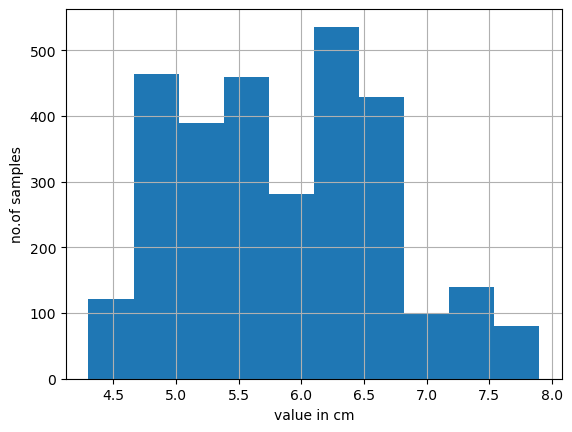

In [104]:
df['sepal length'].hist()
#Giving Label's to x and y asix.
plt.xlabel("value in cm")
plt.ylabel("no.of samples")

Text(0, 0.5, 'no.of samples')

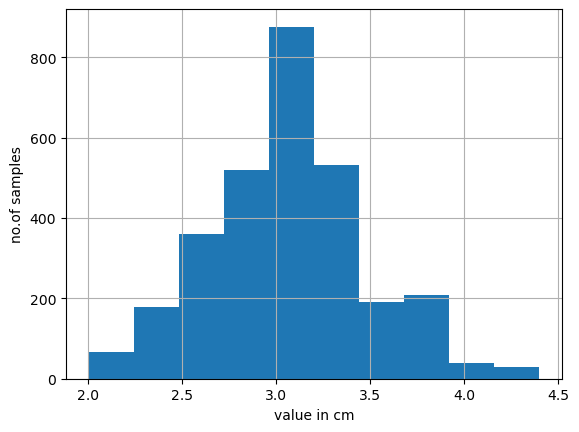

In [105]:
df['sepal width'].hist()
plt.xlabel("value in cm")
plt.ylabel("no.of samples")

Text(0, 0.5, 'no.of samples')

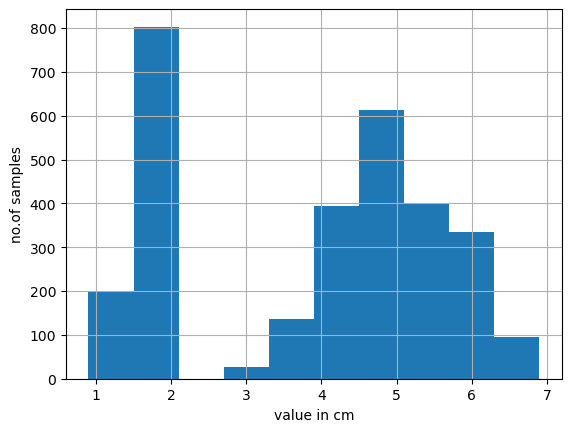

In [106]:
df['petal length'].hist()
plt.xlabel("value in cm")
plt.ylabel("no.of samples")

Text(0, 0.5, 'no.of samples')

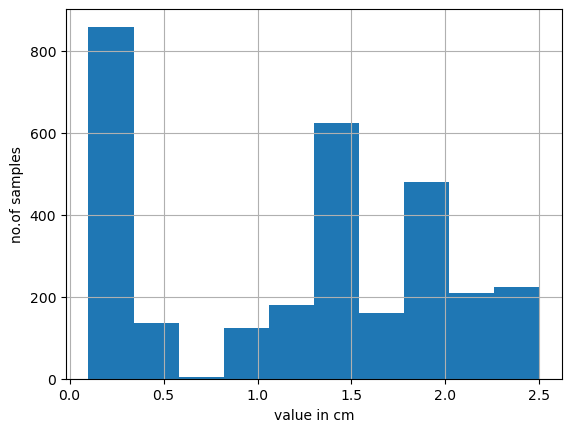

In [107]:
df['petal width'].hist()
plt.xlabel("value in cm")
plt.ylabel("no.of samples")

--> Here if we observe the above four histograms we get an insight that, 

    * "sepal length" and "sepal width" have normal distribution, which means all classes of iris flowers have similar sepal properties.
    * "petal length" and "petal width" have non-normal distribution where two classes are mearged together and other class is 
       seperated.

In [108]:
#scatter plot
colors = ['red' , 'orange' , 'green']
species = ['Iris-setosa' , 'Iris-versicolor' , 'Iris-virginica']

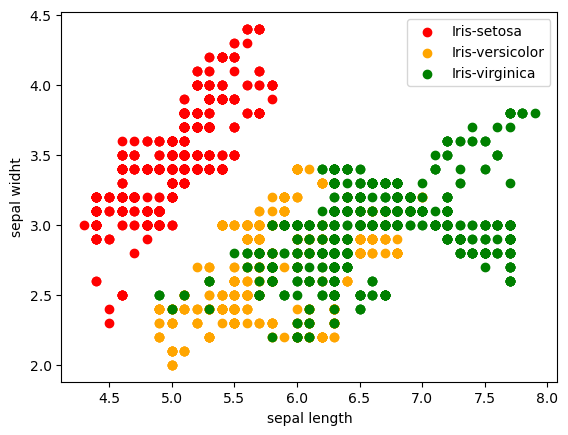

In [134]:
for i in range(3):
    x = df[df['label'] == species[i]] 
    ''' here species[i] indicates the values in species list,
        species[1] = 'Iris-setosa' 
        species[2] = 'Iris-versicolor'
        species[3] = 'Iris-virginica'
        so, we iterate through data frame "label" and check for match of species[i], if it matches, we add it to 'x' dataframe
        '''
    plt.scatter(x['sepal length'], x['sepal width'], c = colors[i], label=species[i]) #plt.scatter(x-cordinates , y-cordinates, color(c) , label)
    '''
        once we got all data into 'x', we are plotting a scatter plot on it.
       (Note:- label is basically used to group all data points from similar species)
    '''
plt.xlabel("sepal length")
plt.ylabel("sepal widht")
plt.legend() #defines which color data point belongs to which class based on label.

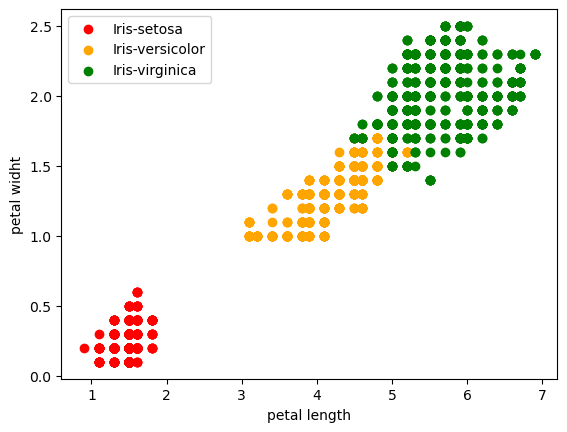

In [133]:
for i in range(3):
    x = df[df['label'] == species[i]] 
    plt.scatter(x['petal length'], x['petal width'], c = colors[i], label=species[i],) 
       
plt.xlabel("petal length")
plt.ylabel("petal widht")
plt.legend()

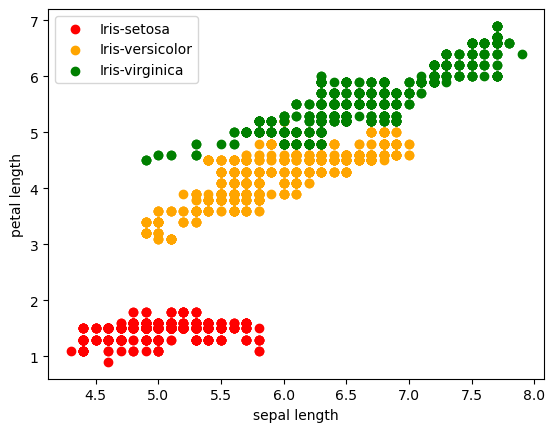

In [132]:
for i in range(3):
    x = df[df['label'] == species[i]] 
    plt.scatter(x['sepal length'], x['petal length'], c = colors[i], label=species[i]) 
       
plt.xlabel("sepal length")
plt.ylabel("petal length")
plt.legend()

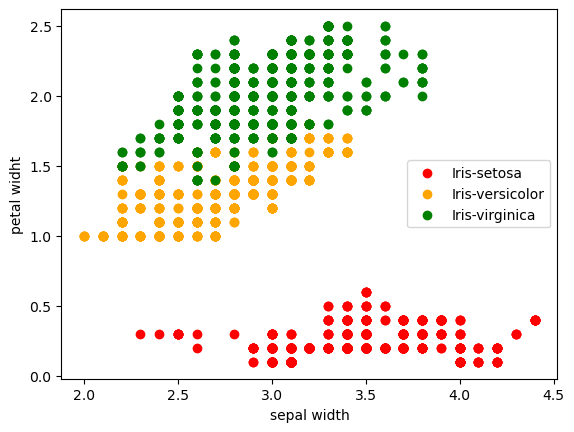

In [112]:
for i in range(3):
    x = df[df['label'] == species[i]] 
    plt.scatter(x['sepal width'], x['petal width'], c = colors[i], label=species[i]) 
       
plt.xlabel("sepal width")
plt.ylabel("petal widht")
plt.legend()

**CORRELATION MATRIX**
  
  A correlarion matrix is a table showing correlation coefficients between variables. Each cell in the table shows the correlation between the two     variables. The values are in the range of -1 to 1. if two variables have high correlation, we can neglect one of them. This helps in reducing the overhead of variables in large datasets.

In [113]:
df_numeric_col = df.drop(columns=['label']) #seperating only numeric columns to find correlation matrix

In [114]:
df_numeric_col.corr() #correlation matrix of numeric columns

,sepal length,sepal width,petal length,petal width
sepal length,1.000000,-0.197603,0.896797,0.853185
sepal width,-0.197603,1.000000,-0.466636,-0.402453
petal length,0.896797,-0.466636,1.000000,0.970774
petal width,0.853185,-0.402453,0.970774,1.000000


**TRAINING MACHINE LEARNING MODEL**

In [115]:
from sklearn.model_selection import train_test_split
#train = 70%
#testing = 30%
X = df.drop(columns=['label']) #input data for train_test_split
Y = df['label'] #output data for train_test_split
x_train , x_test , y_train , y_test = train_test_split(X,Y, test_size=0.30) #splitting data into training data and testing data.

In [123]:
# Decision Tree 
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)

In [124]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**DRAWING DECISION TREE**

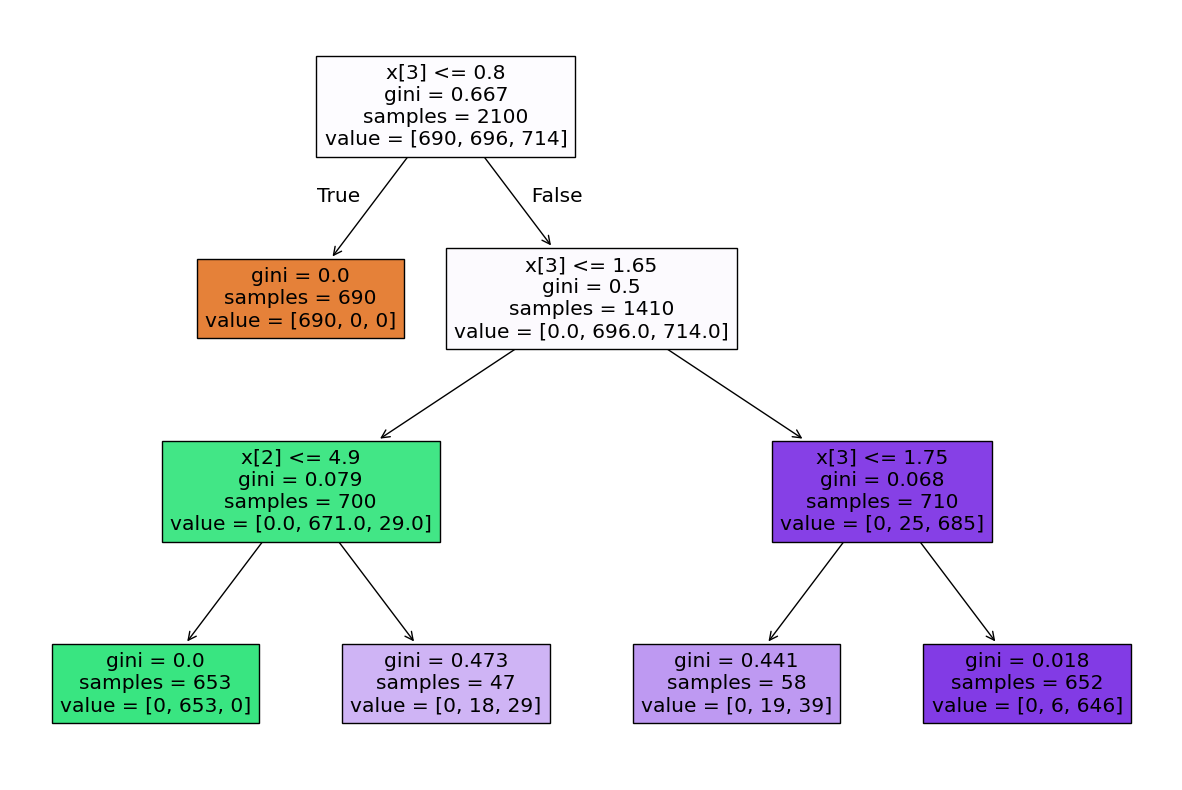

In [125]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True)
plt.show()

**CHECKING PERFORMANCE OF THE MODEL**


In [126]:
y_pred = model.predict(x_test)

In [127]:
from sklearn.metrics import accuracy_score,classification_report

In [128]:
accuracy = accuracy_score(y_pred,y_test)
print(accuracy)

0.9744444444444444


In [129]:
print(classification_report(y_pred,y_test))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00       310
Iris-versicolor       0.92      1.00      0.96       281
 Iris-virginica       1.00      0.93      0.96       309

       accuracy                           0.97       900
      macro avg       0.97      0.98      0.97       900
   weighted avg       0.98      0.97      0.97       900

